# Prerequisites · M2 — Calculus & Vector Calculus for Deep Learning

> **Goal:** the calculus that makes **backpropagation** work — derivatives, partial derivatives, the **gradient**, the **Jacobian**, and the **multivariate chain rule** — built and visualized from scratch, tied to the autograd engine (NB01) and the optimizers (NB04) that use them.

**Why.** Training a neural net = *follow the negative gradient of the loss*. To do that you need: what a derivative *is* (Section 1), how it generalizes to many inputs (the gradient, Section 2) and many outputs (the Jacobian, Section 3), how to compose derivatives through a deep network (the chain rule, Section 4 — literally what `backward()` does), and what the *second* derivative tells you about optimization (the Hessian, Section 6). This is the mathematical spine of the whole repo.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
np.random.seed(0)


## 1. The derivative — slope, sensitivity, and finite differences

The **derivative** $f'(x) = \dfrac{df}{dx}$ is the *slope* of $f$ at $x$ — equivalently, "if I nudge $x$ by a tiny $h$, how much does $f$ change?":
$$f'(x) = \lim_{h\to 0}\frac{f(x+h)-f(x)}{h}.$$
For small $h$ we can *approximate* it numerically (**finite differences**) — the central difference $\frac{f(x+h)-f(x-h)}{2h}$ is the accurate version, and it's exactly how you gradient-checked autograd in NB01.


analytic f'(1.5) = 4.75000
numeric  f'(1.5) = 4.75000  (central difference)


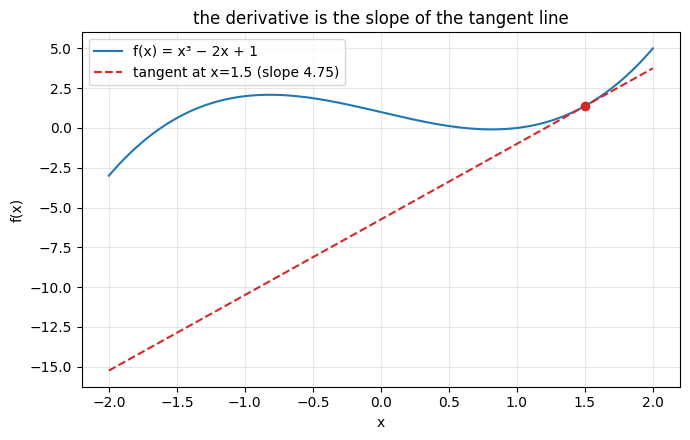

In [2]:
def f(x): return x**3 - 2*x + 1
def df_analytic(x): return 3*x**2 - 2                      # derivative by the power rule
def df_numeric(x, h=1e-5): return (f(x+h)-f(x-h))/(2*h)    # central difference

x0 = 1.5
print(f"analytic f'({x0}) = {df_analytic(x0):.5f}")
print(f"numeric  f'({x0}) = {df_numeric(x0):.5f}  (central difference)")

xs = np.linspace(-2, 2, 200)
fig, ax = plt.subplots(figsize=(7,4.5))
ax.plot(xs, f(xs), label="f(x) = x³ − 2x + 1")
slope = df_analytic(x0)
ax.plot(xs, f(x0) + slope*(xs-x0), "--", color="tab:red", label=f"tangent at x={x0} (slope {slope:.2f})")
ax.scatter([x0],[f(x0)], color="tab:red", zorder=5)
ax.set_title("the derivative is the slope of the tangent line")
ax.set_xlabel("x"); ax.set_ylabel("f(x)"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


**↳ Used in:** the numerical gradient checks throughout Tier 0 (NB01–03) that verify every hand-derived gradient.


## 2. Partial derivatives & the gradient — steepest ascent

Neural nets have *many* inputs (millions of weights). For a function of several variables $f(x_1,\dots,x_n)$, the **partial derivative** $\frac{\partial f}{\partial x_i}$ is the slope in the $x_i$ direction (holding the others fixed). Stack them into the **gradient**:
$$\nabla f = \left[\frac{\partial f}{\partial x_1}, \dots, \frac{\partial f}{\partial x_n}\right].$$
The gradient is a *vector* that points in the direction of **steepest ascent**, and its magnitude is how steep. So to *minimize* a loss, we step in the $-\nabla f$ direction — that's gradient descent. Let's visualize it on a 2-D surface.


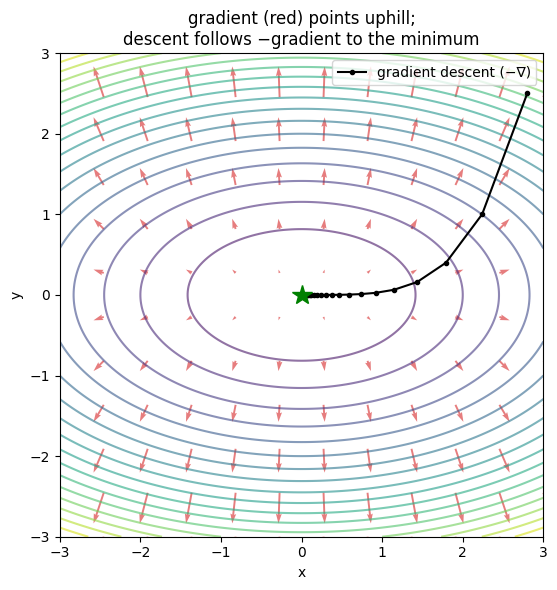

gradient at (1,1): [2 6] -> steepest-ascent direction there


In [3]:
def g(x, y): return x**2 + 3*y**2                          # a bowl (elliptical)
def grad_g(x, y): return np.array([2*x, 6*y])               # [∂/∂x, ∂/∂y]

xs = np.linspace(-3,3,200); ys = np.linspace(-3,3,200); X,Y = np.meshgrid(xs,ys)
fig, ax = plt.subplots(figsize=(6.5,6))
ax.contour(X, Y, g(X,Y), levels=20, cmap="viridis", alpha=0.6)
# gradient arrows on a coarse grid (pointing UPHILL)
gx, gy = np.meshgrid(np.linspace(-3,3,12), np.linspace(-3,3,12))
G = grad_g(gx, gy)
ax.quiver(gx, gy, G[0], G[1], color="tab:red", alpha=0.6, width=0.004)
# gradient DESCENT path (follow -gradient)
p = np.array([2.8, 2.5]); path=[p.copy()]
for _ in range(40):
    p = p - 0.1*grad_g(*p); path.append(p.copy())
path = np.array(path)
ax.plot(path[:,0], path[:,1], "-o", color="black", ms=3, label="gradient descent (−∇)")
ax.plot(0,0,"g*",ms=15)
ax.set_title("gradient (red) points uphill;\ndescent follows −gradient to the minimum")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.legend(); ax.set_aspect("equal")
plt.tight_layout(); plt.show()
print("gradient at (1,1):", grad_g(1,1), "-> steepest-ascent direction there")


**↳ Used in:** *every* optimizer (NB04) — they all compute $\nabla_\theta L$ and step against it; the "loss surface" plots in NB04 are exactly this picture.


## 3. The Jacobian — derivatives of vector → vector maps

When a function maps a **vector to a vector** $f:\mathbb{R}^n\to\mathbb{R}^m$ (like a neural net layer), its derivative is a *matrix* — the **Jacobian** $J$, where $J_{ij} = \frac{\partial f_i}{\partial x_j}$ (row $i$ = gradient of output $i$). It's the best *linear approximation* of $f$ near a point: $f(x+\delta) \approx f(x) + J\delta$. The Jacobian is the bridge between calculus and the linear algebra of M1 — locally, every smooth map *is* a matrix (its Jacobian).


In [4]:
# f(x,y) = [x^2 + y, sin(x)*y, x - y^2]  : R^2 -> R^3
def fvec(v):
    x,y = v; return np.array([x**2 + y, np.sin(x)*y, x - y**2])
def jacobian_analytic(v):
    x,y = v
    return np.array([[2*x,        1.0     ],     # ∂f1/∂x, ∂f1/∂y
                     [np.cos(x)*y, np.sin(x)],    # ∂f2/∂x, ∂f2/∂y
                     [1.0,        -2*y     ]])    # ∂f3/∂x, ∂f3/∂y
def jacobian_numeric(f, v, h=1e-5):
    m = len(f(v)); J = np.zeros((m, len(v)))
    for j in range(len(v)):
        vp = v.copy(); vp[j]+=h; vm = v.copy(); vm[j]-=h
        J[:,j] = (f(vp)-f(vm))/(2*h)               # column j = ∂f/∂x_j
    return J

v = np.array([0.7, -1.2])
Ja, Jn = jacobian_analytic(v), jacobian_numeric(fvec, v)
print("analytic Jacobian:\n", np.round(Ja,4))
print("max abs err vs numeric:", np.abs(Ja-Jn).max())
assert np.abs(Ja-Jn).max() < 1e-6
print("✅ Jacobian (matrix of all partial derivatives) verified")


analytic Jacobian:
 [[ 1.4     1.    ]
 [-0.9178  0.6442]
 [ 1.      2.4   ]]
max abs err vs numeric: 2.3756441258626637e-11
✅ Jacobian (matrix of all partial derivatives) verified


**↳ Used in:** the softmax Jacobian derivation (NB02), the $\log|\det J|$ in normalizing flows (NB26), and conceptually every layer's backward pass *is* a Jacobian-vector product (autograd never forms the full Jacobian — it multiplies by it implicitly, which is why it's efficient).


## 4. The multivariate chain rule — this IS backpropagation

The chain rule composes derivatives: if $z = f(y)$ and $y = g(x)$, then $\frac{dz}{dx} = \frac{dz}{dy}\frac{dy}{dx}$. For **multiple paths** (a variable influencing the output through several routes), you **sum** the contributions:
$$\frac{\partial L}{\partial x} = \sum_{\text{paths}} \frac{\partial L}{\partial (\cdot)}\frac{\partial(\cdot)}{\partial x}.$$
A deep network is a long composition $L = f_n(f_{n-1}(\dots f_1(x)))$, so its gradient is a **product of Jacobians**, applied right-to-left. **That's backpropagation** — and the "sum over paths" is exactly the `+=` accumulation you wrote in NB01. Let's verify the chain rule numerically on a small composition.


In [5]:
# L(x) = sin(a*x)^2 where a=1.5 ; compute dL/dx by the chain rule vs numerically
a = 1.5
def L(x):
    u = a*x            # inner
    s = np.sin(u)      # middle
    return s**2        # outer
def dL_chain(x):
    u = a*x; s = np.sin(u)
    dL_ds = 2*s        # dL/ds
    ds_du = np.cos(u)  # ds/du
    du_dx = a          # du/dx
    return dL_ds * ds_du * du_dx    # chain them
x0 = 0.9
print(f"chain rule dL/dx = {dL_chain(x0):.6f}")
print(f"numeric   dL/dx = {(L(x0+1e-6)-L(x0-1e-6))/2e-6:.6f}")

# the "sum over paths" rule: L = h(x) + h(x) reuse; d/dx = 2 h'(x)
def h(x): return x**2
print(f"\nreuse: L=h(x)+h(x)=2x², dL/dx at x=3 by summing both paths = {2*3 + 2*3} (=12, i.e. 2·(2x))")
print("that 'sum the paths' is the += accumulation in every _backward (NB01).")


chain rule dL/dx = 0.641070
numeric   dL/dx = 0.641070

reuse: L=h(x)+h(x)=2x², dL/dx at x=3 by summing both paths = 12 (=12, i.e. 2·(2x))
that 'sum the paths' is the += accumulation in every _backward (NB01).


**↳ Used in:** the *entire* autograd engine (NB01–02) — `backward()` is the chain rule executed in reverse topological order, accumulating gradients over all paths. Everything trainable in this repo rests on this cell.


## 5. Why *reverse*-mode? (forward vs backward)

The chain rule can be evaluated left-to-right (**forward mode**) or right-to-left (**reverse mode**). For a neural net — **many inputs** (millions of parameters), **one output** (a scalar loss) — reverse mode is dramatically cheaper: it computes *all* input gradients in a single backward pass costing ~the same as one forward pass. Forward mode would need one pass *per input*. That asymmetry is the whole reason deep learning uses backpropagation (reverse mode) and not forward-mode autodiff.


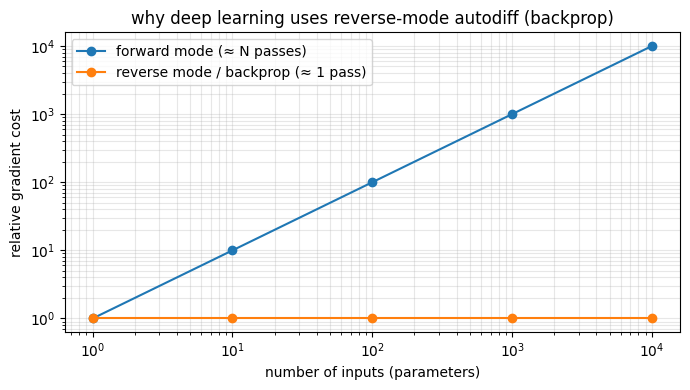

In [6]:
# cost intuition: to get gradients of a scalar L wrt N inputs
N = np.array([1, 10, 100, 1000, 10000])
forward_cost = N            # forward mode: ~1 pass per input
reverse_cost = np.ones_like(N)   # reverse mode: ~1 pass total (for a scalar output)
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(N, forward_cost, "-o", label="forward mode (≈ N passes)")
ax.plot(N, reverse_cost, "-o", label="reverse mode / backprop (≈ 1 pass)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_title("why deep learning uses reverse-mode autodiff (backprop)")
ax.set_xlabel("number of inputs (parameters)"); ax.set_ylabel("relative gradient cost"); ax.legend(); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()


**↳ Used in:** the design of the whole autograd engine (NB01) — it's reverse-mode precisely because loss is one scalar and parameters are many.


## 6. The Hessian & curvature — the second derivative

The **Hessian** $H$ is the matrix of *second* partial derivatives, $H_{ij} = \frac{\partial^2 f}{\partial x_i \partial x_j}$ — it describes the **curvature** of the loss surface. Its eigenvalues tell you the shape: all positive → a **bowl** (convex minimum); mixed signs → a **saddle** (flat in some directions, curved in others — the things that slow down training). The ratio of largest to smallest eigenvalue is the **condition number**, which controls how fast gradient descent converges (the "zig-zag" in NB04 is a badly-conditioned Hessian).


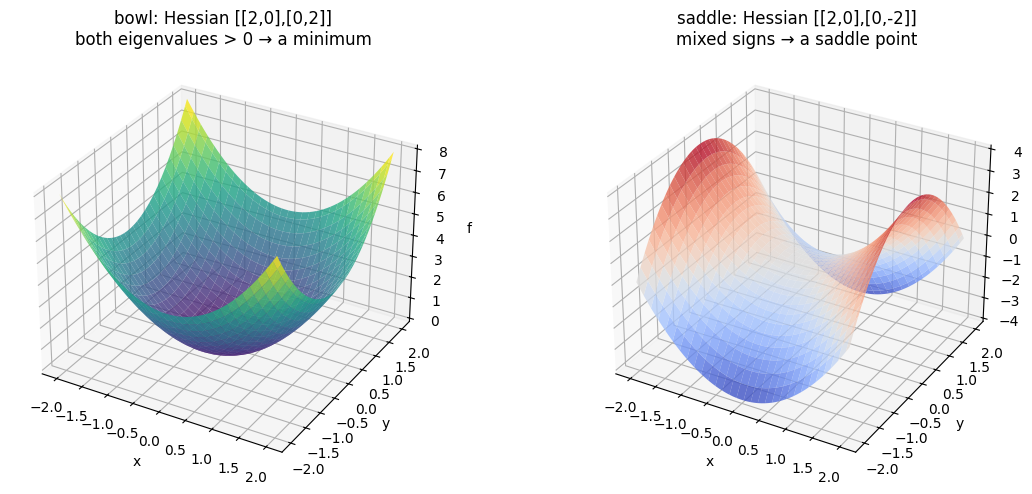

loss a·x²+b·y² with (a,b)=(1,1): Hessian condition number = 1  (well-conditioned)
loss a·x²+b·y² with (a,b)=(1,10): Hessian condition number = 10  (ill-conditioned → slow / zig-zag)
loss a·x²+b·y² with (a,b)=(1,50): Hessian condition number = 50  (ill-conditioned → slow / zig-zag)


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), subplot_kw={"projection":"3d"})
xs = np.linspace(-2,2,60); X,Y = np.meshgrid(xs,xs)
ax[0].plot_surface(X, Y, X**2 + Y**2, cmap="viridis", alpha=0.8)
ax[0].set_title("bowl: Hessian [[2,0],[0,2]]\nboth eigenvalues > 0 → a minimum")
ax[1].plot_surface(X, Y, X**2 - Y**2, cmap="coolwarm", alpha=0.8)
ax[1].set_title("saddle: Hessian [[2,0],[0,-2]]\nmixed signs → a saddle point")
for a in ax: a.set_xlabel("x"); a.set_ylabel("y"); a.set_zlabel("f")
plt.tight_layout(); plt.show()

# condition number governs convergence speed (recall NB04's zig-zag)
for a, b in [(1,1),(1,10),(1,50)]:
    H = np.array([[2*a,0],[0,2*b]]); cond = np.linalg.cond(H)
    print(f"loss a·x²+b·y² with (a,b)=({a},{b}): Hessian condition number = {cond:.0f}  "
          f"({'well-conditioned' if cond<5 else 'ill-conditioned → slow / zig-zag'})")


**↳ Used in:** understanding *why* momentum and Adam help (NB04) — they combat ill-conditioning (a wide Hessian eigenvalue spread); the ravine that made plain SGD zig-zag is a high-condition-number Hessian. Second-order methods (Newton's method) use $H^{-1}$ directly.

## What you learned
- **Derivative**: slope / sensitivity; verified by finite differences (the gradient-check tool).
- **Gradient**: the vector of partials pointing uphill; descent follows $-\nabla$ (every optimizer).
- **Jacobian**: the derivative of a vector→vector map — a matrix; the local linearization.
- **Multivariate chain rule**: composing derivatives with sum-over-paths — *this is backprop*.
- **Reverse mode**: why backprop (one scalar loss, many params) is far cheaper than forward mode.
- **Hessian / curvature**: second derivatives; condition number governs optimization speed.

## Exercises
1. **Softmax Jacobian.** Derive $\partial p_i/\partial z_j = p_i(\delta_{ij}-p_j)$ and verify numerically (you used this in NB02).
2. **Directional derivative.** Show $\nabla f\cdot u$ gives the slope in direction $u$, maximized when $u\parallel\nabla f$.
3. **Backprop by hand.** For $L=(\sigma(wx+b)-y)^2$, derive $\partial L/\partial w$ via the chain rule; compare to autograd.
4. **Jacobian-vector product.** Compute $Jv$ without forming $J$ (forward-mode); and $J^{\mathsf T}u$ (reverse-mode) — the two autodiff primitives.
5. **Newton step.** For a 1-D quadratic, show Newton's method $x-f'/f''$ reaches the minimum in one step; why don't we use full Newton in DL?
6. **Saddle escape.** On $x^2-y^2$, start gradient descent near the saddle; how long to escape? (Relates to why saddles slow training.)

## 📚 References & further reading
- **Deep Learning** — Goodfellow, Bengio & Courville (2016), Chapter 4 ("Numerical Computation") and Section 6.5 ("Back-Propagation").
- **Automatic differentiation in machine learning: a survey** — Baydin et al. (2018), JMLR. Forward vs reverse mode, rigorously.
- **Calculus on Manifolds** — Spivak. The rigorous treatment of the Jacobian and multivariable chain rule.
- **The Matrix Calculus You Need For Deep Learning** — Parr & Howard (2018), arXiv:1802.01528. Exactly the vector-calculus subset used in DL.

---
**Next:** *Prerequisites · M3 — Probability & statistics*: random variables, distributions, expectation, maximum likelihood, and Bayes — the foundation of loss functions, VAEs (NB23), and flows (NB26).
